# Benchmark - [Google's Gemma 4 31B](https://huggingface.co/unsloth/gemma-4-31B-it-GGUF)

**Evaluation:** Tasks 01-06, excl. 03

**Hardware:** Apple M5 Max 128GB

In [1]:
import textwrap

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.patches import Patch

from benchmark_lib import (
  DATA_DIR,
  RUNS_PER_BATCH,
  SERIES,
  add_token_counts,
  compare_skills,
  latest_batches,
  load_runs,
  metric_table,
  plot_benchmark,
  plot_skill_summary,
  plot_timeouts,
  save_runs,
)

HARDWARE = "Apple M5 Max 128GB"
MODEL_LABEL = "Gemma 4 31B"


In [2]:
MODEL_NAME = "gemma-4-31b"
benchmark_dir = DATA_DIR / "google" / MODEL_NAME

if (not benchmark_dir.exists()):
  all_runs = load_runs(model=MODEL_NAME, hardware=HARDWARE)
  df = add_token_counts(latest_batches(all_runs))
  save_runs(df, benchmark_dir, redact=("openai",))


In [3]:
benchmark = pd.read_csv(benchmark_dir / "benchmark.csv")
benchmark["start_time"] = pd.to_datetime(benchmark["start_time"])
benchmark.head()


,task,run,start_time,skills,score,points,total,passed,structure_match,duration_seconds,...,model,harness,model_server,hardware,fields,input_tokens,output_tokens,cache_read_tokens,cache_write_tokens,total_tokens
0,01-data-loading,20260815_133506,2026-08-15 13:35:06.336540,True,1.0,5,5,True,True,279,...,gemma-4-31B-Q4_K_XL,pi,llama.cpp,Apple M5 Max 128GB,"{'n_cells': {'expected': 20857, 'actual': 2085...",14832,4272,125461,0,144565
1,01-data-loading,20260815_133946,2026-08-15 13:39:46.401282,True,1.0,5,5,True,True,373,...,gemma-4-31B-Q4_K_XL,pi,llama.cpp,Apple M5 Max 128GB,"{'n_cells': {'expected': 20857, 'actual': 2085...",14390,5953,185324,0,205667
2,01-data-loading,20260815_134600,2026-08-15 13:46:00.379529,True,1.0,5,5,True,True,373,...,gemma-4-31B-Q4_K_XL,pi,llama.cpp,Apple M5 Max 128GB,"{'n_cells': {'expected': 20857, 'actual': 2085...",12409,5908,216828,0,235145
3,01-data-loading,20260815_135213,2026-08-15 13:52:13.762399,True,1.0,5,5,True,True,312,...,gemma-4-31B-Q4_K_XL,pi,llama.cpp,Apple M5 Max 128GB,"{'n_cells': {'expected': 20857, 'actual': 2085...",12328,4731,198721,0,215780
4,01-data-loading,20260815_135726,2026-08-15 13:57:26.929406,True,1.0,5,5,True,True,279,...,gemma-4-31B-Q4_K_XL,pi,llama.cpp,Apple M5 Max 128GB,"{'n_cells': {'expected': 20857, 'actual': 2085...",9218,4657,141823,0,155698


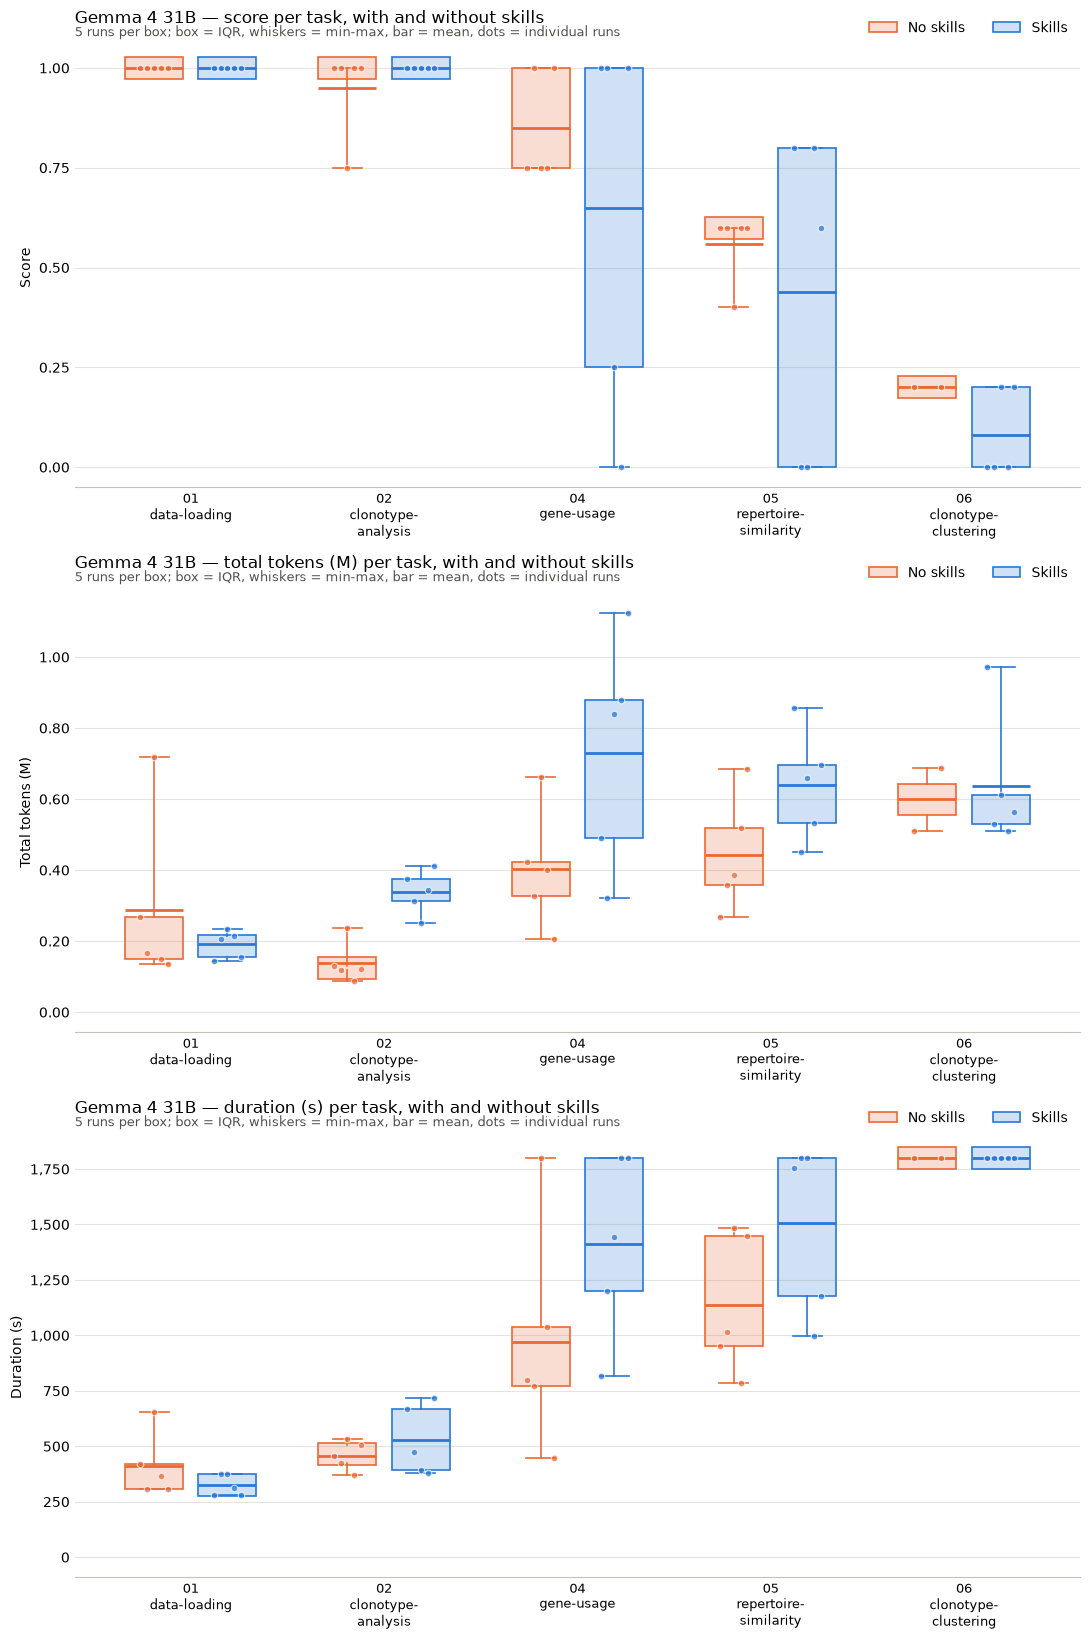

In [4]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(11, 5.5 * 3))
plot_benchmark(benchmark, column="score", model_label=MODEL_LABEL, ax=axs[0])
plot_benchmark(benchmark, column="total_tokens", model_label=MODEL_LABEL, ax=axs[1])
plot_benchmark(benchmark, column="duration_seconds", model_label=MODEL_LABEL, ax=axs[2])
fig.tight_layout()
plt.show()


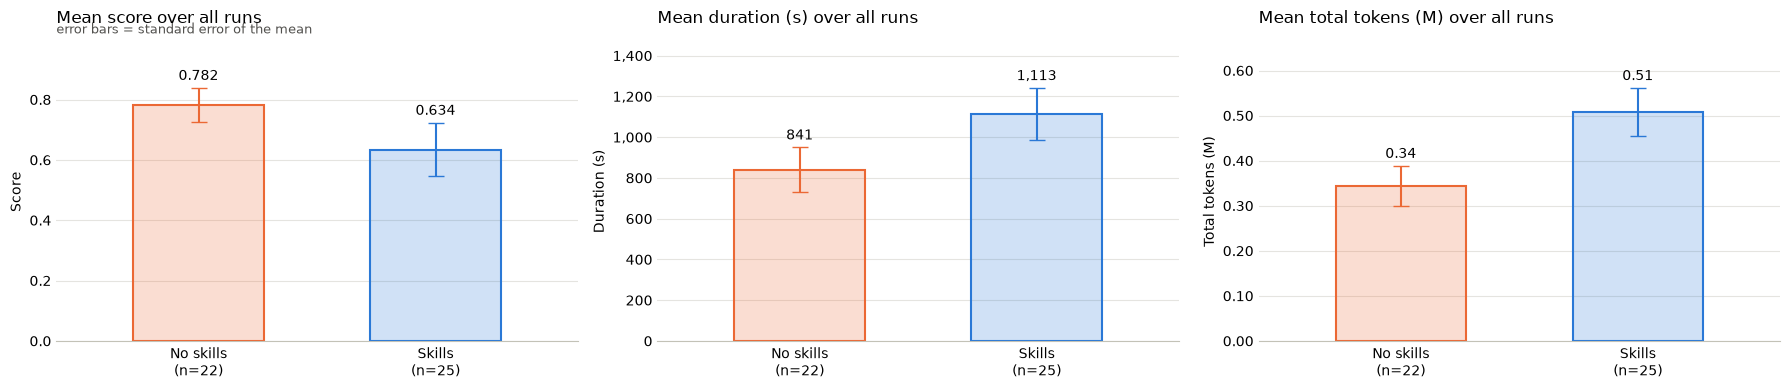

In [5]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(6 * 3, 4))
plot_skill_summary(benchmark, axs=axs)
fig.tight_layout()
plt.show()


In [6]:
significance = compare_skills(benchmark)


In [7]:
metric_table(significance, "score")


,scope,test,n,mean_no_skills,mean_skills,diff,p_value,p_fdr,significant_fdr
0,all tasks (pooled),Mann-Whitney U,22 vs 25,0.781818,0.634,-0.147818,0.505606,NaN,False
1,01-data-loading,Mann-Whitney U,5 vs 5,1.000000,1.000,0.000000,1.000000,1.0,False
2,02-clonotype-analysis,Mann-Whitney U,5 vs 5,0.950000,1.000,0.050000,0.423711,1.0,False
3,04-gene-usage,Mann-Whitney U,5 vs 5,0.850000,0.650,-0.200000,1.000000,1.0,False
4,05-repertoire-similarity,Mann-Whitney U,5 vs 5,0.560000,0.440,-0.120000,1.000000,1.0,False
5,06-clonotype-clustering,Mann-Whitney U,2 vs 5,0.200000,0.080,-0.120000,0.263552,1.0,False
6,all tasks (paired by task),Wilcoxon signed-rank,5 tasks,0.712000,0.634,-0.078000,0.250000,NaN,False


In [8]:
metric_table(significance, "duration_seconds")


,scope,test,n,mean_no_skills,mean_skills,diff,p_value,p_fdr,significant_fdr
0,all tasks (pooled),Mann-Whitney U,22 vs 25,840.681818,1113.48,272.798182,0.228593,NaN,False
1,01-data-loading,Mann-Whitney U,5 vs 5,411.600000,323.20,-88.400000,0.400525,0.667542,False
2,02-clonotype-analysis,Mann-Whitney U,5 vs 5,458.200000,526.80,68.600000,0.690476,0.863095,False
3,04-gene-usage,Mann-Whitney U,5 vs 5,972.200000,1412.00,439.800000,0.138792,0.356142,False
4,05-repertoire-similarity,Mann-Whitney U,5 vs 5,1137.000000,1505.40,368.400000,0.142457,0.356142,False
5,06-clonotype-clustering,Mann-Whitney U,2 vs 5,1800.000000,1800.00,0.000000,1.000000,1.000000,False
6,all tasks (paired by task),Wilcoxon signed-rank,5 tasks,955.800000,1113.48,157.680000,0.375000,NaN,False


In [9]:
metric_table(significance, "total_tokens")


,scope,test,n,mean_no_skills,mean_skills,diff,p_value,p_fdr,significant_fdr
0,all tasks (pooled),Mann-Whitney U,22 vs 25,344075.954545,507451.92,163375.965455,0.035726,NaN,False
1,01-data-loading,Mann-Whitney U,5 vs 5,288328.800000,191371.00,-96957.800000,1.000000,1.000000,False
2,02-clonotype-analysis,Mann-Whitney U,5 vs 5,139187.800000,339280.80,200093.000000,0.007937,0.039683,True
3,04-gene-usage,Mann-Whitney U,5 vs 5,403946.600000,730776.60,326830.000000,0.150794,0.251323,False
4,05-repertoire-similarity,Mann-Whitney U,5 vs 5,442901.200000,638944.60,196043.400000,0.095238,0.238095,False
5,06-clonotype-clustering,Mann-Whitney U,2 vs 5,598924.500000,636886.60,37962.100000,1.000000,1.000000,False
6,all tasks (paired by task),Wilcoxon signed-rank,5 tasks,374657.780000,507451.92,132794.140000,0.187500,NaN,False


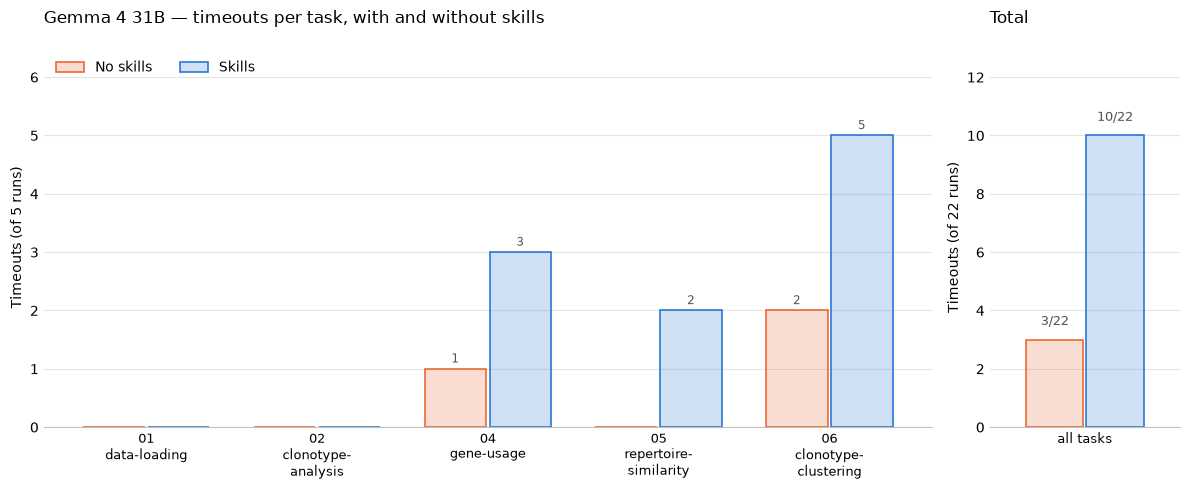

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [7, 1.5]})
plot_timeouts(benchmark, model_label=MODEL_LABEL, axs=axs)
fig.tight_layout()
plt.show()